# Medical Device Risk Class Prediction — EDA & Preprocessing
### Cognizant AI Hackathon — Team Notebook

**Task**: Predict `risk_class` (I / II / III) for medical devices using the ICIJ Implant Files dataset
(recalls, safety alerts, field safety notices).

**Key finding from initial analysis**: clean `risk_class` labels exist for only ~32.6k of 118k device
records, and **100% of those labeled records are USA-sourced**. This notebook documents that limitation,
builds a leakage-safe feature set, and produces a clean train/test split + fitted preprocessing pipeline
for the modeling stage.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import joblib
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

DATA_DIR = Path('../dataset')
OUT_DIR = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

# Backend ML directory — preprocessor.pkl will be copied here after fitting
BACKEND_ML_DIR = Path('../backend/app/ml')
BACKEND_ML_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load raw data

In [2]:
devices = pd.read_csv(DATA_DIR / 'devices-1681209661.csv', low_memory=False)
events = pd.read_csv(DATA_DIR / 'events-1681209680.csv', low_memory=False)
manufacturers = pd.read_csv(DATA_DIR / 'manufacturers-1681209657.csv', low_memory=False)

print(f"devices:       {devices.shape}")
print(f"events:        {events.shape}")
print(f"manufacturers: {manufacturers.shape}")


devices:       (118249, 15)
events:        (124969, 30)
manufacturers: (31827, 10)


## 2. Target variable (`risk_class`) — audit

Before doing anything else, we check how usable this label actually is.

In [3]:
print("Raw risk_class value counts:")
print(devices['risk_class'].value_counts(dropna=False))


Raw risk_class value counts:
risk_class
NaN               85301
2                 24693
1                  5654
3                  2255
Unclassified        242
Not Classified       86
HDE                  16
II                    2
Name: count, dtype: int64


In [4]:
print(f"Missing risk_class: {devices['risk_class'].isna().mean():.1%}")

# Only 1/2/3 are clean, usable classes. 'Unclassified', 'Not Classified', 'HDE', 'II' are
# junk / inconsistent entries that don't belong in a clean 3-class scheme.
usable = devices[devices['risk_class'].isin(['1', '2', '3'])].copy()
usable['risk_class'] = usable['risk_class'].astype(int)

print(f"\nUsable labeled rows: {len(usable):,} of {len(devices):,} ({len(usable)/len(devices):.1%})")
print(f"Countries represented in usable subset: {usable['country'].unique()}")


Missing risk_class: 72.1%

Usable labeled rows: 32,602 of 118,249 (27.6%)
Countries represented in usable subset: <StringArray>
['USA']
Length: 1, dtype: str


**Finding**: after dropping missing and junk labels, only 32,602 rows remain — and every single one
is `country == 'USA'`. This means the model we train is really *"predict FDA device risk class from
device metadata,"* not a global failure-prediction model, even though the source data spans ~30 countries.
This must be stated explicitly in the presentation.

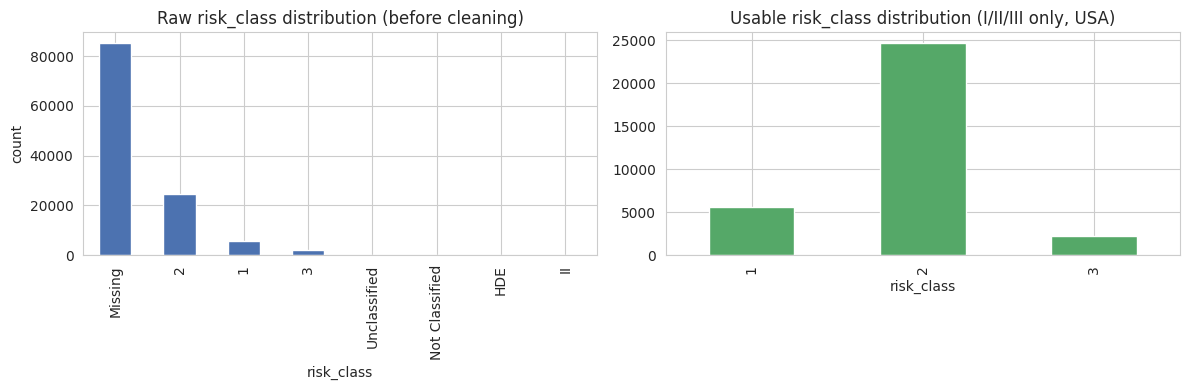

risk_class
1    0.173
2    0.757
3    0.069
Name: proportion, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

devices['risk_class'].fillna('Missing').value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Raw risk_class distribution (before cleaning)')
axes[0].set_ylabel('count')

usable['risk_class'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Usable risk_class distribution (I/II/III only, USA)')
axes[1].set_xlabel('risk_class')

plt.tight_layout()
plt.savefig(OUT_DIR / 'target_distribution.png', dpi=110)
plt.show()

print(usable['risk_class'].value_counts(normalize=True).sort_index().round(3))


**Class imbalance**: class 2 ≈ 76%, class 1 ≈ 17%, class 3 ≈ 7%. Plain accuracy would be
misleading here — a model that always predicts class 2 gets ~76% "accuracy" while being useless.
We'll use **macro-F1** and per-class precision/recall as the real metrics, and use a **stratified**
train/test split so all three classes are proportionally represented in both sets.

## 3. Missingness across device features

In [6]:
missing_pct = (devices.isna().sum() / len(devices) * 100).sort_values(ascending=False)
print(missing_pct.round(1))


quantity_in_commerce    73.0
risk_class              72.1
distributed_to          71.6
implanted               70.5
classification          69.9
code                    69.4
number                  46.0
description             24.2
name                     0.0
country                  0.0
id                       0.0
slug                     0.0
manufacturer_id          0.0
created_at               0.0
updated_at               0.0
dtype: float64


In [7]:
missing_usable = (usable.isna().sum() / len(usable) * 100).sort_values(ascending=False)
print("Missingness WITHIN the usable (labeled) subset:")
print(missing_usable.round(2))


Missingness WITHIN the usable (labeled) subset:
quantity_in_commerce    5.14
number                  1.23
classification          0.73
distributed_to          0.10
code                    0.01
description             0.01
id                      0.00
name                    0.00
implanted               0.00
risk_class              0.00
slug                    0.00
country                 0.00
manufacturer_id         0.00
created_at              0.00
updated_at              0.00
dtype: float64


Within the usable subset, `classification` (device category) and `description` are both
~99%+ populated — these are our two strongest raw features. `distributed_to`, `implanted`,
`quantity_in_commerce` and `number` remain sparse even in the labeled subset and are dropped.

## 4. Device category (`classification`) vs risk_class

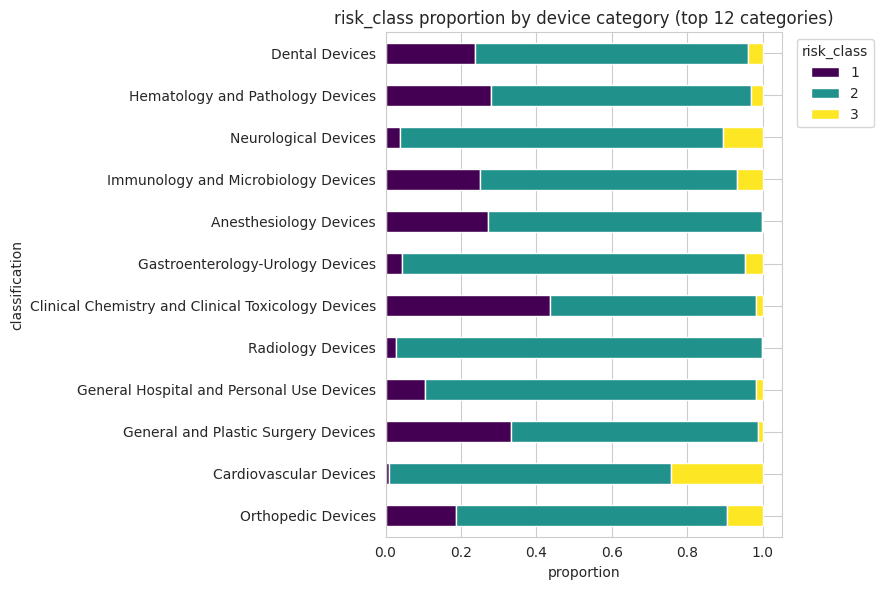

In [8]:
ct = pd.crosstab(usable['classification'], usable['risk_class'], normalize='index')
ct = ct.loc[usable['classification'].value_counts().head(12).index]  # top 12 categories by volume

fig, ax = plt.subplots(figsize=(9, 6))
ct.plot(kind='barh', stacked=True, ax=ax, colormap='viridis')
ax.set_title('risk_class proportion by device category (top 12 categories)')
ax.set_xlabel('proportion')
ax.legend(title='risk_class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR / 'category_vs_riskclass.png', dpi=110)
plt.show()


Risk class varies meaningfully by device category (e.g. cardiovascular/implant-heavy categories
skew toward higher risk classes), confirming `classification` is a genuinely predictive, non-leaky
feature — it describes *what the device is*, not anything about its recall history.

## 5. Events data — leakage check

`events.csv` links to devices via `device_id`. It's tempting to engineer features like
"number of recalls for this device" or "worst action_classification for this device" — but this is
**data leakage**: many devices are classified into risk_class *because of* their recall/safety history,
so device-level event features would let the model see an outcome that's entangled with the label
itself, inflating validation scores without generalizing to a real prediction scenario (predicting risk
class for a *new* device with no recall history yet).

**Rule for this project: no device-level event fields are used as model features.** We only use
event data aggregated at the **manufacturer** level — a manufacturer's overall track record across
its whole portfolio, which is legitimately known before any single new device is classified.

In [9]:
# Manufacturer-level aggregates (leakage-safe: describes the manufacturer's overall history,
# not this specific device's own recall outcome)
events_with_mfr = events.merge(
    devices[['id', 'manufacturer_id']].rename(columns={'id': 'device_id'}),
    on='device_id', how='left'
)

mfr_features = events_with_mfr.groupby('manufacturer_id').agg(
    mfr_total_events=('id', 'count'),
    mfr_distinct_countries=('country', 'nunique'),
    mfr_distinct_devices_recalled=('device_id', 'nunique'),
).reset_index()

# severity mix: normalize action_classification text, then get % of events that were high-severity
def normalize_action_class(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x in ('1', 'i', 'class 1', 'class i'):
        return 'I'
    if x in ('2', 'ii', 'class 2', 'class ii'):
        return 'II'
    if x in ('3', 'iii', 'class 3', 'class iii'):
        return 'III'
    return np.nan

events_with_mfr['action_class_norm'] = events_with_mfr['action_classification'].apply(normalize_action_class)
severity_share = (
    events_with_mfr.groupby('manufacturer_id')['action_class_norm']
    .apply(lambda s: (s == 'I').mean())
    .reset_index(name='mfr_pct_class1_events')
)

mfr_features = mfr_features.merge(severity_share, on='manufacturer_id', how='left')
print(mfr_features.shape)
mfr_features.head()


(31716, 5)


,manufacturer_id,mfr_total_events,mfr_distinct_countries,mfr_distinct_devices_recalled,mfr_pct_class1_events
0,1,1,1,1,0.0
1,2,1,1,1,0.0
2,3,1,1,1,0.0
3,4,1,1,1,0.0
4,5,1,1,1,0.0


## 6. Assemble the modeling table

Join: `usable devices` (target + classification + description) + `manufacturer-level aggregates`.
No device-level event fields enter this table.

In [10]:
model_df = usable[['id', 'classification', 'description', 'manufacturer_id', 'risk_class']].copy()
model_df = model_df.merge(mfr_features, on='manufacturer_id', how='left')

# a device whose manufacturer has zero recorded events elsewhere gets 0 / NaN -> fill sensibly
model_df['mfr_total_events'] = model_df['mfr_total_events'].fillna(0)
model_df['mfr_distinct_countries'] = model_df['mfr_distinct_countries'].fillna(0)
model_df['mfr_distinct_devices_recalled'] = model_df['mfr_distinct_devices_recalled'].fillna(0)
model_df['mfr_pct_class1_events'] = model_df['mfr_pct_class1_events'].fillna(0)
model_df['classification'] = model_df['classification'].fillna('Unknown')
model_df['description'] = model_df['description'].fillna('')

print(model_df.shape)
model_df.head()


(32602, 9)


,id,classification,description,manufacturer_id,risk_class,mfr_total_events,mfr_distinct_countries,mfr_distinct_devices_recalled,mfr_pct_class1_events
0,12530,General Hospital and Personal Use Devices,"Replacement LED PCB Kit, part number 001840, o...",4827,2,14,1,14,0.071429
1,12531,General Hospital and Personal Use Devices,ACCU-CHEK Tender II 13/80 10 + 10 pieces || Pr...,4828,2,84,1,84,0.000000
2,12532,General Hospital and Personal Use Devices,ACCU-CHEK Tender II 13/110 10 + 10 pieces || P...,4828,2,84,1,84,0.000000
3,12533,General Hospital and Personal Use Devices,ACCU-CHEK Tender II 17/60 10 + 10 pieces || Pr...,4828,2,84,1,84,0.000000
4,12534,General Hospital and Personal Use Devices,ACCU-CHEK Tender II 17/80 10 + 10 pieces || Pr...,4828,2,84,1,84,0.000000


In [11]:
print("Final missingness check:")
print(model_df.isna().sum())


Final missingness check:
id                               0
classification                   0
description                      0
manufacturer_id                  0
risk_class                       0
mfr_total_events                 0
mfr_distinct_countries           0
mfr_distinct_devices_recalled    0
mfr_pct_class1_events            0
dtype: int64


## 7. Basic text signal check — description length by risk_class

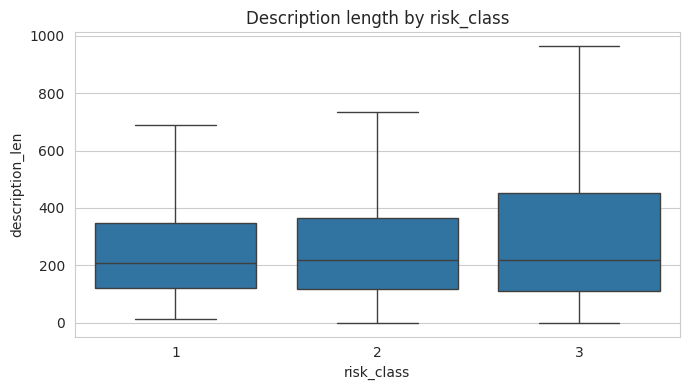

risk_class
1    209.0
2    218.0
3    220.0
Name: description_len, dtype: float64

In [12]:
model_df['description_len'] = model_df['description'].str.len()

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=model_df, x='risk_class', y='description_len', ax=ax, showfliers=False)
ax.set_title('Description length by risk_class')
plt.tight_layout()
plt.savefig(OUT_DIR / 'description_length_by_class.png', dpi=110)
plt.show()

model_df.groupby('risk_class')['description_len'].median()


## 8. Train / test split (stratified)

Given the class imbalance (76% / 17% / 7%), we stratify the split so both sets have proportional
representation of all three classes — otherwise the smallest class (III, ~7%) could be badly
under-represented in either split by chance.

In [13]:
from sklearn.model_selection import train_test_split

X = model_df.drop(columns=['risk_class', 'id'])
y = model_df['risk_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))


Train: (26081, 8), Test: (6521, 8)

Train class distribution:
risk_class
1    0.173
2    0.757
3    0.069
Name: proportion, dtype: float64

Test class distribution:
risk_class
1    0.173
2    0.757
3    0.069
Name: proportion, dtype: float64


## 9. Preprocessing pipeline

- `description` → TF-IDF (free text, the richest single signal)
- `classification` → one-hot encoded (16 categories)
- manufacturer aggregate numerics → passed through / scaled

This pipeline is **fit only on X_train** and reused (never refit) at inference time, to avoid any
train/test leakage and to match production behavior — the same fitted object FastAPI will load.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

numeric_features = ['mfr_total_events', 'mfr_distinct_countries',
                     'mfr_distinct_devices_recalled', 'mfr_pct_class1_events', 'description_len']
categorical_features = ['classification']
text_feature = 'description'

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('text', TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1, 2)), text_feature),
])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"Transformed train shape: {X_train_transformed.shape}")
print(f"Transformed test shape:  {X_test_transformed.shape}")


Transformed train shape: (26081, 522)
Transformed test shape:  (6521, 522)


## 10. Save artifacts for the modeling notebook / FastAPI backend

In [15]:
joblib.dump(preprocessor, OUT_DIR / 'preprocessor.pkl')

# Also save as pipeline.pkl to backend/app/ml/ — this is what FastAPI loads at startup
import shutil
shutil.copy(OUT_DIR / 'preprocessor.pkl', BACKEND_ML_DIR / 'pipeline.pkl')
print('pipeline.pkl copied to backend/app/ml/')

X_train.assign(risk_class=y_train.values).to_csv(OUT_DIR / 'train.csv', index=False)
X_test.assign(risk_class=y_test.values).to_csv(OUT_DIR / 'test.csv', index=False)

summary = {
    'usable_labeled_rows': int(len(usable)),
    'total_device_rows': int(len(devices)),
    'usable_pct': round(len(usable) / len(devices), 4),
    'labeled_countries': usable['country'].unique().tolist(),
    'class_distribution': usable['risk_class'].value_counts(normalize=True).sort_index().round(4).to_dict(),
    'n_classification_categories': int(usable['classification'].nunique()),
    'n_manufacturers': int(usable['manufacturer_id'].nunique()),
    'train_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),
    'features_used': numeric_features + categorical_features + [text_feature],
    'leakage_note': 'No device-level event fields used as features; only manufacturer-level aggregates.',
}

with open(OUT_DIR / 'eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))


{
  "usable_labeled_rows": 32602,
  "total_device_rows": 118249,
  "usable_pct": 0.2757,
  "labeled_countries": [
    "USA"
  ],
  "class_distribution": {
    "1": 0.1734,
    "2": 0.7574,
    "3": 0.0692
  },
  "n_classification_categories": 16,
  "n_manufacturers": 3783,
  "train_rows": 26081,
  "test_rows": 6521,
  "features_used": [
    "mfr_total_events",
    "mfr_distinct_countries",
    "mfr_distinct_devices_recalled",
    "mfr_pct_class1_events",
    "description_len",
    "classification",
    "description"
  ],
  "leakage_note": "No device-level event fields used as features; only manufacturer-level aggregates."
}


## Summary for the team

- **Target scope**: model predicts `risk_class` for USA-registered devices only (32,602 labeled rows)
  — state this explicitly in the presentation, don't imply global coverage.
- **Imbalance**: use macro-F1 / per-class precision-recall, not accuracy, as the headline metric.
- **Leakage guardrail**: only manufacturer-level event aggregates are used as features; device-level
  event history is deliberately excluded.
- **Artifacts saved to `outputs/`**: `preprocessor.pkl`, `train.csv`, `test.csv`, `eda_summary.json`,
  plus the three PNG charts — ready for the modeling notebook (Logistic Regression → Random Forest →
  XGBoost) and for the FastAPI backend to eventually load the same fitted `preprocessor.pkl`.
